<a href="https://colab.research.google.com/github/camilaalmeiida/wine-quality-classification/blob/main/notebookfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Tech Challenge — Classificação de Qualidade de Vinhos
**Objetivo**: Desenvolver um modelo de Machine Learning capaz de prever se um vinho é de alta qualidade (nota ≥ 7) ou baixa/média qualidade (nota < 7), com base em suas características físico-químicas.

Pipeline:

Compreensão do Problema

Análise Exploratória de Dados (EDA)

Pré-processamento

Desenvolvimento de Modelos

Avaliação e Comparação

Interpretação dos Resultados

##1. Compreensão do Problema
● Interpretar o contexto do problema.

● Definir claramente a variável alvo.

● Realizar a transformação da variável de qualidade em classificação binária.

In [5]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [6]:
# Importar os dados da base WineQT, com delimitador do arquivo por virgula
df = pd.read_csv('WineQT.csv', sep= ",")

In [7]:
# Remove a coluna Id pois não tem nenhuma utilidade para o modelo de classificação
df = df.drop(columns=['Id'], errors='ignore')

In [8]:
# Total de linhas e colunas
df.shape

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5


In [9]:
# Criação da variavel binaria 1 → Alta Qualidade: nota ≥ 7 e 0 → Baixa/Média Qualidade: nota < 7
df['high_quality'] = (df['quality'] >= 7).astype(int)

In [14]:
# Verificação da distribuição da variável original e da binária criada
print('Distribuição das notas originais de qualidade:')
print(df['quality'].value_counts().sort_index())
print()
print('Distribuição da variável-alvo binária (high_quality):')
print(df['high_quality'].value_counts())
print()

# Percentual de vinhos de acordo com a classe
pct = df['high_quality'].value_counts(normalize=True) * 100
print(f'  Baixa/Média qualidade (0): {pct[0]:.1f}%')
print(f'  Alta qualidade        (1): {pct[1]:.1f}%')

Distribuição das notas originais de qualidade:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Distribuição da variável-alvo binária (high_quality):
high_quality
0    984
1    159
Name: count, dtype: int64

  Baixa/Média qualidade (0): 86.1%
  Alta qualidade        (1): 13.9%


##2. Análise Exploratória de Dados (EDA)
● Investigar a distribuição das variáveis.

● Identificar correlações entre as variáveis e justificar cada uma delas.

● Detectar possíveis outliers ou valores inconsistentes.

● Analisar o balanceamento das classes.

In [15]:
#Descrição do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  high_quality          1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [16]:
# Verificar se há valores nulos na base
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [17]:
# Média, desvio padrão, mín, máx e quartis de cada variável
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,high_quality
count,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000
mean,8.311,0.531,0.268,2.532,0.087,15.615,45.915,0.997,3.311,0.658,10.442,5.657,0.139
std,1.748,0.180,0.197,1.356,0.047,10.250,32.782,0.002,0.157,0.170,1.082,0.806,0.346
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000,0.000
25%,7.100,0.392,0.090,1.900,0.070,7.000,21.000,0.996,3.205,0.550,9.500,5.000,0.000
50%,7.900,0.520,0.250,2.200,0.079,13.000,37.000,0.997,3.310,0.620,10.200,6.000,0.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,61.000,0.998,3.400,0.730,11.100,6.000,0.000
max,15.900,1.580,1.000,15.500,0.611,68.000,289.000,1.004,4.010,2.000,14.900,8.000,1.000


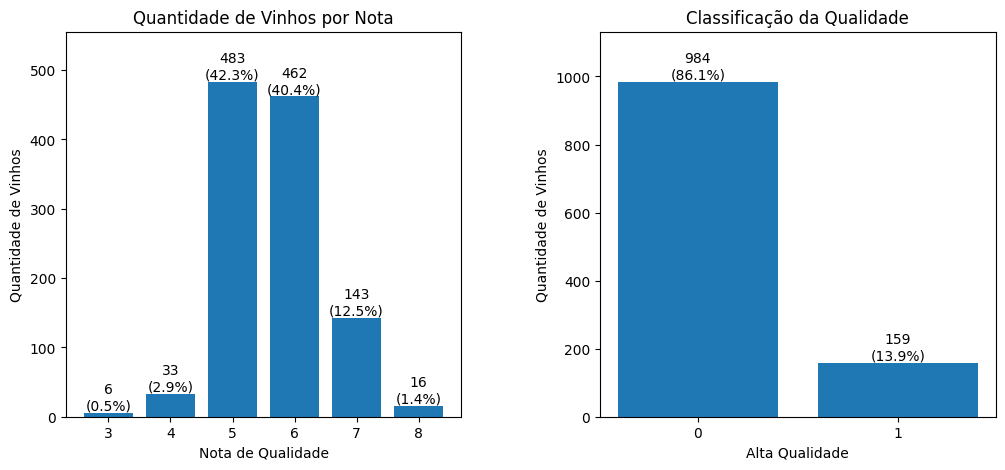

In [18]:
import matplotlib.pyplot as plt

# Contagem das notas originais
notas = df["quality"].value_counts().sort_index()

# Contagem da classificação binária
qtd_notas = df["high_quality"].value_counts().sort_index()

# Criar dois gráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ---------------- Gráfico 1 ----------------
barras1 = ax[0].bar(notas.index, notas.values)

# Percentuais
percentual1 = notas / notas.sum() * 100

# Rótulos
rotulos1 = [f'{qtd}\n({perc:.1f}%)' for qtd, perc in zip(notas.values, percentual1)]
ax[0].bar_label(barras1, labels=rotulos1)

ax[0].set_xlabel("Nota de Qualidade")
ax[0].set_ylabel("Quantidade de Vinhos")
ax[0].set_title("Quantidade de Vinhos por Nota")

# ---------------- Gráfico 2 ----------------
barras2 = ax[1].bar(qtd_notas.index.astype(str), qtd_notas.values)

# Percentuais
percentual2 = qtd_notas / qtd_notas.sum() * 100

# Rótulos
rotulos2 = [f'{qtd}\n({perc:.1f}%)' for qtd, perc in zip(qtd_notas.values, percentual2)]
ax[1].bar_label(barras2, labels=rotulos2)

ax[1].set_xlabel("Alta Qualidade")
ax[1].set_ylabel("Quantidade de Vinhos")
ax[1].set_title("Classificação da Qualidade")

# Ajustar limite do eixo Y
ax[0].set_ylim(0, max(notas.values) * 1.15)
ax[1].set_ylim(0, max(qtd_notas.values) * 1.15)

# Espaço entre os gráficos
plt.subplots_adjust(wspace=0.35)

plt.show()

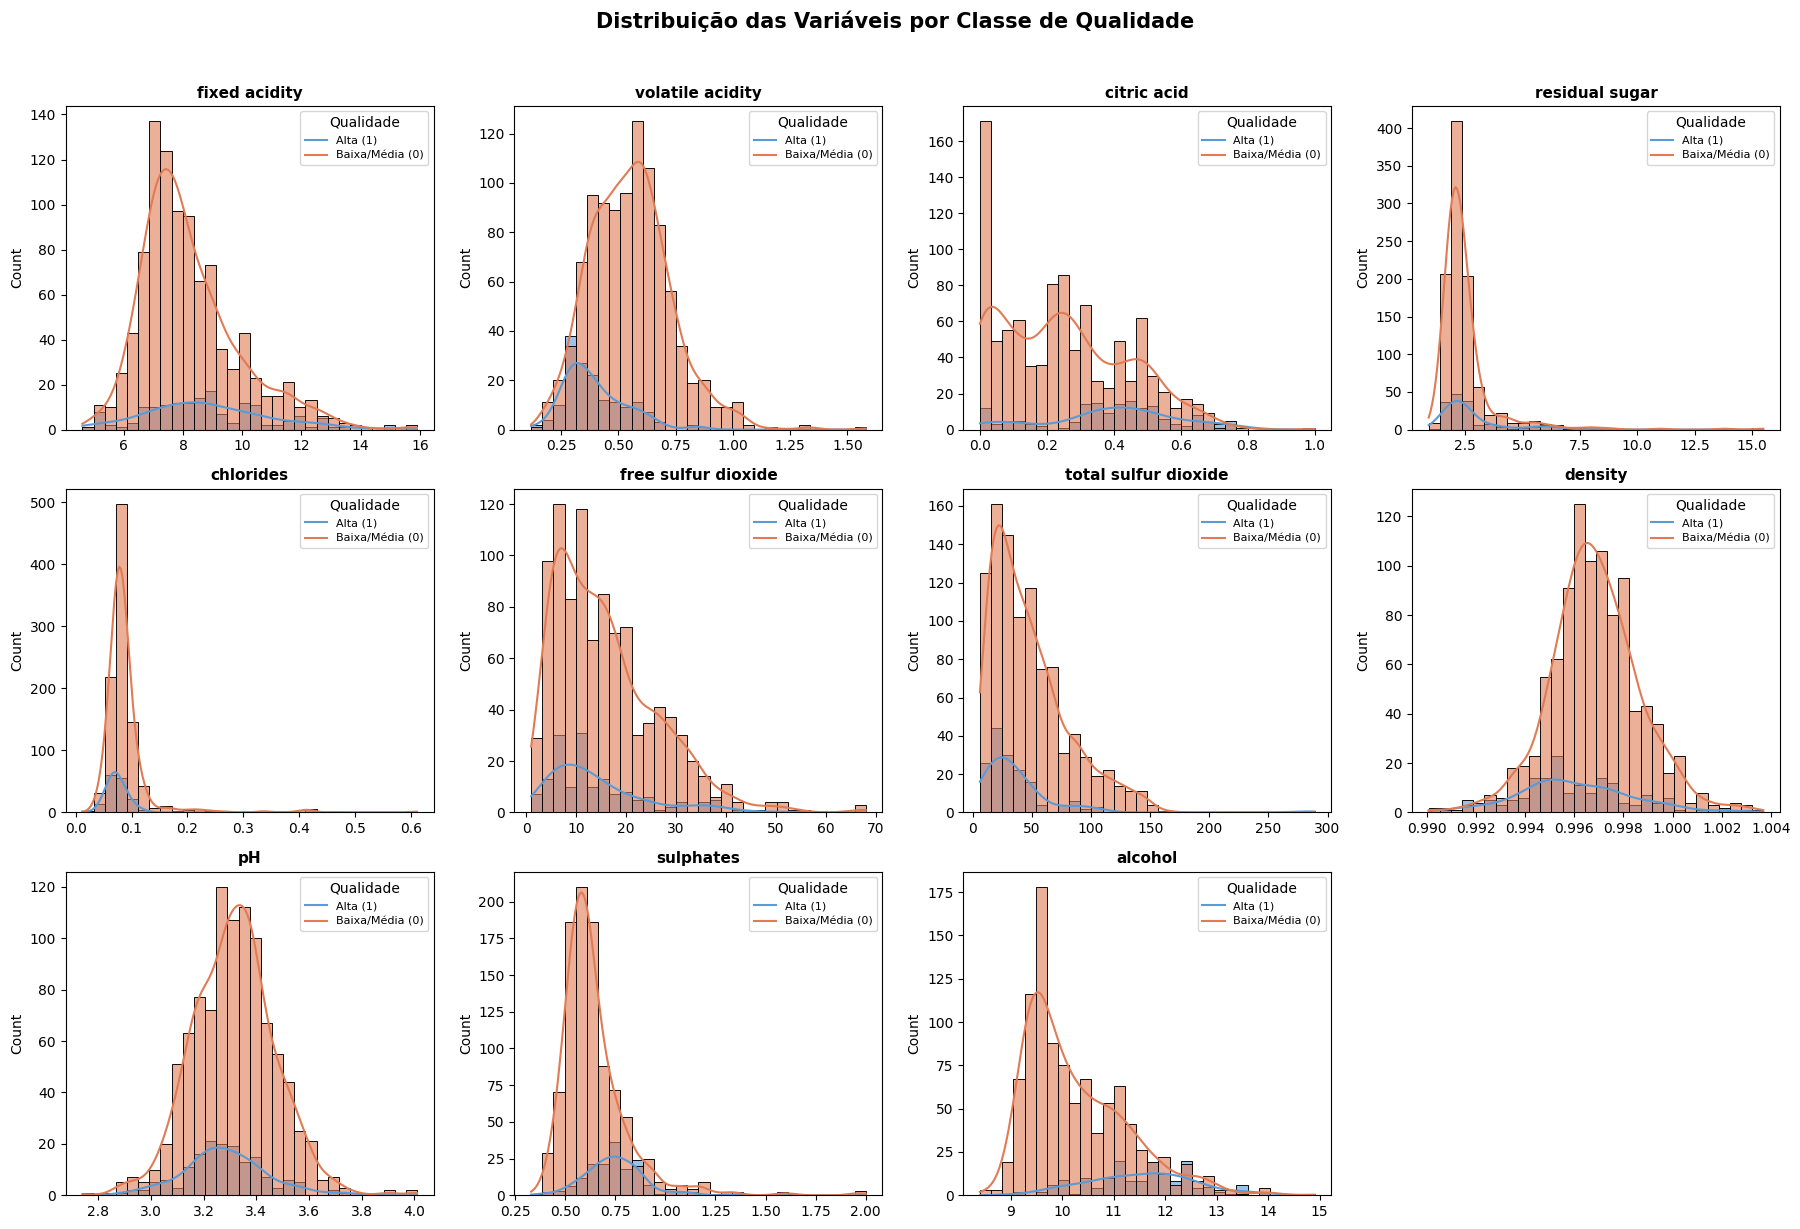

In [19]:
# Histogramas com curva KDE (estimativa de densidade) para entender o formato da distribuição de cada feature.
features = [c for c in df.columns if c not in ['quality', 'high_quality']]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    # hue='high_quality' mostra como a distribuição difere entre as classes
    sns.histplot(data=df, x=col, hue='high_quality', kde=True, ax=axes[i],
                 palette={0: '#E07B54', 1: '#5B9BD5'}, alpha=0.6, bins=30)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='Qualidade', labels=['Alta (1)', 'Baixa/Média (0)'], fontsize=8)

# Remove subplots extras
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Variáveis por Classe de Qualidade', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()

In [20]:
# Identificação de Outliers
# Método: valores abaixo de Q1 - 1.5*IQR ou acima de Q3 + 1.5*IQR
# são considerados outliers
print('Quantidade de outliers por variável (método IQR):\n')
outlier_summary = {}
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = n_out / len(df) * 100
    outlier_summary[col] = n_out
    print(f'  {col:<28}: {n_out:>4} outliers ({pct_out:.1f}%)')

Quantidade de outliers por variável (método IQR):

  fixed acidity               :   44 outliers (3.8%)
  volatile acidity            :   14 outliers (1.2%)
  citric acid                 :    1 outliers (0.1%)
  residual sugar              :  110 outliers (9.6%)
  chlorides                   :   77 outliers (6.7%)
  free sulfur dioxide         :   18 outliers (1.6%)
  total sulfur dioxide        :   40 outliers (3.5%)
  density                     :   36 outliers (3.1%)
  pH                          :   20 outliers (1.7%)
  sulphates                   :   43 outliers (3.8%)
  alcohol                     :   12 outliers (1.0%)


Optamos por MANTER os outliers, pois em dados de vinho eles podem
   representar características reais de amostras extremas, não erros.
   

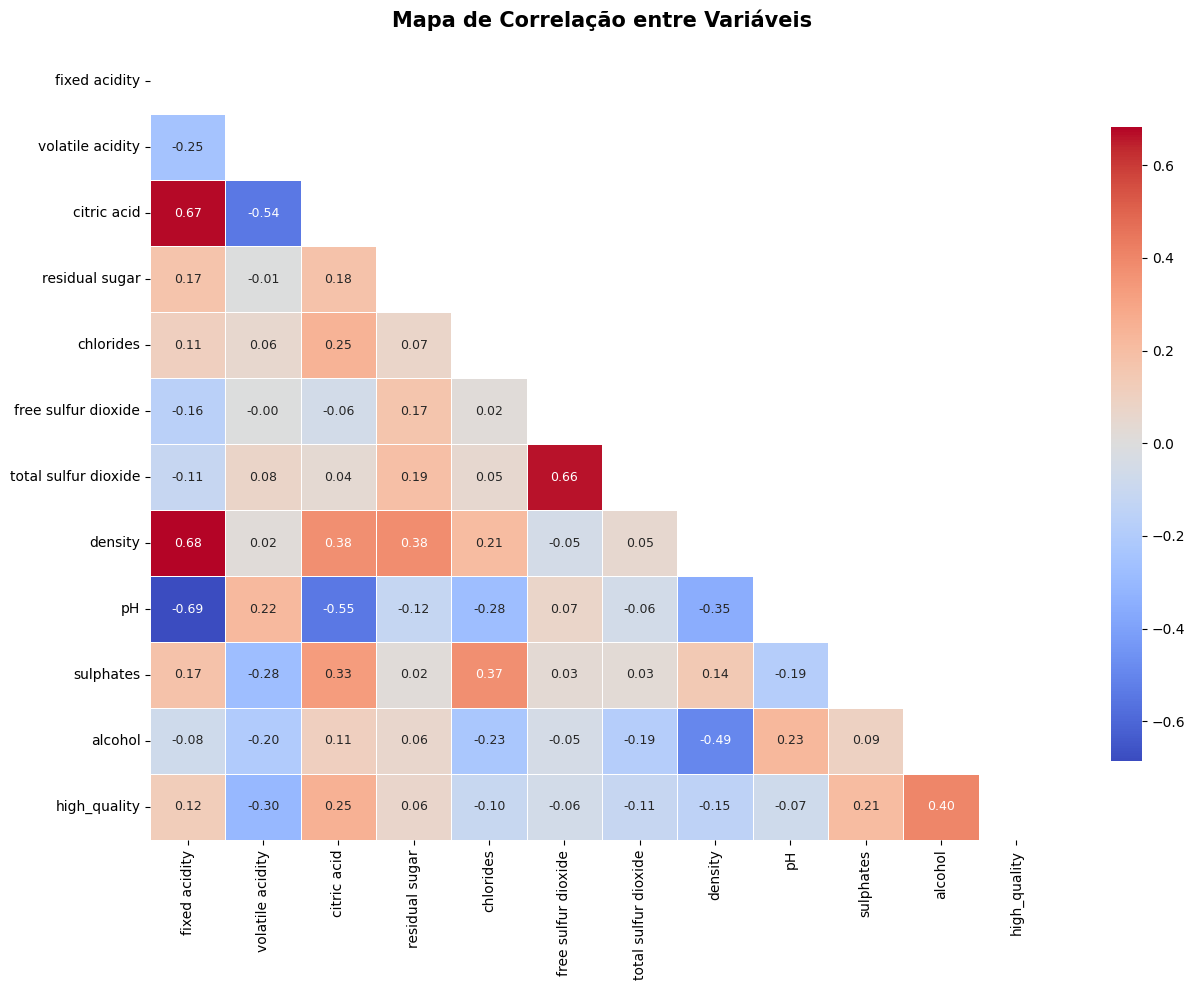


Correlação de cada variável com a qualidade binária (high_quality):
  ▲ alcohol                     : +0.404
  ▼ volatile acidity            : -0.305
  ▲ citric acid                 : +0.251
  ▲ sulphates                   : +0.208
  ▼ density                     : -0.149
  ▲ fixed acidity               : +0.123
  ▼ total sulfur dioxide        : -0.113
  ▼ chlorides                   : -0.104
  ▼ pH                          : -0.073
  ▲ residual sugar              : +0.064
  ▼ free sulfur dioxide         : -0.056


In [21]:
# A correlação de Pearson mede a relação linear entre as variáveis.
# Valores próximos a +1 ou -1 indicam forte correlação.
fig, ax = plt.subplots(figsize=(13, 10))

# Calcula a matriz de correlação (excluindo 'quality' original)
corr_cols = features + ['high_quality']
corr_matrix = df[corr_cols].corr()

# Máscara para ocultar o triângulo superior (evita repetição)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})

ax.set_title('Mapa de Correlação entre Variáveis', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Destacar correlações com a variável-alvo
print('\nCorrelação de cada variável com a qualidade binária (high_quality):')
target_corr = corr_matrix['high_quality'].drop('high_quality').sort_values(key=abs, ascending=False)
for var, val in target_corr.items():
    direction = '▲' if val > 0 else '▼'
    print(f'  {direction} {var:<28}: {val:+.3f}')

In [12]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,0
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,1
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,1
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,0
